# Text-to-Image Search with Milvus

文本到图像搜索是一种先进技术，允许用户通过自然语言文本描述来搜索图像。它利用预训练的多模态模型，将文本和图像转换为共享语义空间中的嵌入向量，从而实现基于相似度的比较。

在本教程中，我们将探讨如何使用 OpenAI 的 Chinese-CLIP（对比式语言-图像预训练）模型与 Milvus 实现基于文本的图像检索。我们将使用 CLIP 生成图像嵌入，将其存储在 Milvus 中，并高效地执行相似性搜索。

## 先决条件
开始之前，请确保已准备好所有必需的软件包和示例数据。

### Install dependencies
- pymilvus>=2.4.2 for interacting with the Milvus database
- clip for working with the CLIP model
- pillow for image processing and visualization

In [1]:
import os

os.environ['NLTK_DATA'] = r'F:\Teewon\Milvue\model\nltk_data'

CUSTOM_CACHE = r'F:\Teewon\Milvue\models'
os.environ['HF_HOME'] = CUSTOM_CACHE
os.environ['HF_HUB_CACHE'] = os.path.join(CUSTOM_CACHE, 'hub')
os.environ['TORCH_HOME'] = CUSTOM_CACHE

In [2]:
import dotenv

dotenv.load_dotenv('../.env')

True

### 下载示例数据
我们将使用 ImageNet 数据集的一个子集（100 个类别，每个类别 10 张图像）作为示例图片。以下命令将下载示例数据并提取到本地文件夹 `./data/reverse_image_search` 中：

### 设置 Milvus
在继续之前，请先配置您的 Milvus 服务器，并使用您的 URI（可选地使用令牌）进行连接：

- Milvus Lite（推荐用于便捷操作）：将 URI 设置为本地文件，例如 ./milvus.db。这会自动启用 Milvus Lite，将所有数据存储在一个文件中。
- Docker 或 Kubernetes（用于大规模数据）：若需处理更大规模的数据集，建议使用 Docker 或 Kubernetes 部署性能更高的 Milvus 服务器。
- Zilliz Cloud（托管服务）：如果您正在使用 Zilliz Cloud（Zilliz 的托管云服务），请将公共端点设置为 URI，API 密钥设置为令牌。

In [3]:
from pymilvus import MilvusClient

mc=MilvusClient(uri="http://localhost:19530")

## 入门指南
现在你已经具备必要的依赖和数据，接下来就是设置特征提取器并开始使用 Milvus。本节将带你一步步完成构建文本到图像搜索系统的关键步骤。最后，我们将演示如何根据文本查询来检索和可视化图像。

### 定义特征提取器
我们将使用预训练的 CLIP 模型生成图像和文本的嵌入向量。在本节中，我们将加载预训练的 CLIP **ViT-B/32** 变体，并定义用于编码图像和文本的辅助函数：

- `encode_image(image_path)`：处理并编码图像为特征向量
- `encode_text(text)`：将文本查询编码为特征向量

这两个函数都会对输出特征进行归一化处理，通过将向量转换为单位长度，确保比较结果的一致性，这对于准确计算余弦相似度至关重要。

In [4]:
import torch
from PIL import Image
from transformers import ChineseCLIPProcessor, ChineseCLIPModel

model_name="OFA-Sys/chinese-clip-vit-base-patch16"
model=ChineseCLIPModel.from_pretrained(model_name)
preprocess=ChineseCLIPProcessor.from_pretrained(model_name)

model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/753M [00:00<?, ?B/s]

ChineseCLIPModel(
  (text_model): ChineseCLIPTextModel(
    (embeddings): ChineseCLIPTextEmbeddings(
      (word_embeddings): Embedding(21128, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ChineseCLIPTextEncoder(
      (layer): ModuleList(
        (0-11): 12 x ChineseCLIPTextLayer(
          (attention): ChineseCLIPTextAttention(
            (self): ChineseCLIPTextSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ChineseCLIPTextSelfOutput(
              (dense): Linear(in_features=768, out

In [9]:
def encoder_image(image_path):
    image=Image.open(image_path)
    inputs=preprocess(images=image,return_tensors="pt")
    with torch.no_grad():
        image_features=model.get_image_features(**inputs)
    image_features=image_features/image_features.norm(p=2,dim=-1,keepdim=True)
    return image_features.squeeze().tolist()

def encoder_text(text):
    inputs=preprocess(text=[text],padding=True,return_tensors="pt")

    # print(f"input_ids shape: {inputs['input_ids'].shape}")
    with torch.no_grad():
        # 直接用 text_model 拿 last_hidden_state，绕开 get_text_features 的 pooler 问题
        text_output=model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
        )
        # 用 [CLS] token（第 0 位）的隐层作为 pooled 表示
        pooled=text_output.last_hidden_state[:,0,:]
        text_features=model.text_projection(pooled)
    text_features=text_features/text_features.norm(p=2,dim=-1,keepdim=True)
    return text_features.squeeze().tolist()

### 数据导入
为了实现语义图像搜索，我们首先需要为所有图像生成嵌入向量，并将其存储在向量数据库中，以便高效地进行索引和检索。本节将提供将图像数据导入 Milvus 的逐步指南。

**1. 创建 Milvus 集合**

在存储图像嵌入之前，您需要先创建一个 Milvus 集合。以下代码展示了如何使用快速入门模式创建集合，并采用默认的 COSINE 指数类型。该集合包含以下字段：

- `id`：启用自动 ID 的主字段。

- `vector`：用于存储浮点向量嵌入的字段。

如需自定义数据结构，请参考 Milvus 文档获取详细说明。

In [6]:
collection_name = "image_collection"

if mc.has_collection(collection_name):
    mc.drop_collection(collection_name)

mc.create_collection(
    collection_name,
    dimension=512,
    auto_id=True,
    enable_dynamic_fields=True,
    overwrite=True,
)

**2. 将数据插入 Milvus**

在此步骤中，我们使用预定义的图像编码器为示例数据目录中的所有 JPEG 图像生成嵌入向量。这些嵌入向量将与对应的文件路径一并插入到 Milvus 集合中。集合中的每个条目包含：

- **Embedding vector嵌入向量**：图像的数值表示，存储在 vector 字段中。
- **File path文件路径**：图像文件的位置，作为动态字段存储在 filepath 字段中。

In [7]:
from glob import glob
image_dir="./data/reverse_image_search/train"
raw_data=[]

for image_path in glob(os.path.join(image_dir,"**/*.JPEG")):
    image_embedding=encoder_image(image_path)
    image_dict={"vector":image_embedding,"filepath":image_path}
    raw_data.append(image_dict)
insert_results=mc.insert(collection_name=collection_name,data=raw_data)

# print(insert_results)
print(f"Inserted {insert_results["insert_count"]},images into milvus")

Inserted 1000,images into milvus


### 执行搜索
现在，我们使用一个示例文本查询来运行搜索。这将根据给定文本描述的语义相似性，检索出最相关的图像。

In [10]:
query_text = "a white dog"
query_embedding=encoder_text(query_text)

search_results=mc.search(
    collection_name=collection_name,
    data=[query_embedding],
    limit=10,
    output_fields=['filepath'],
)

In [12]:
print(search_results[0][0])

{'id': 468794702638886286, 'distance': 0.48024773597717285, 'entity': {'filepath': './data/reverse_image_search/train\\Afghan_hound\\n02088094_2164.JPEG'}}


Visualize results:

Query text: a white dog

Search results:


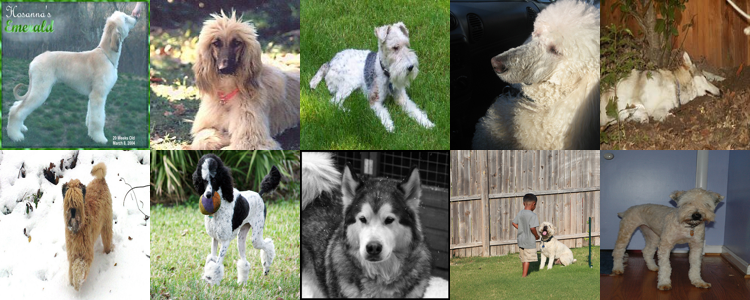

In [13]:
from IPython.display import display

width=150*5
height=150*2
concatenated_image=Image.new("RGB",(width,height))

result_images=[]
for result in search_results:
    for hit in result:
        filename=hit['entity']['filepath']
        img=Image.open(filename)
        img=img.resize((150,150))
        result_images.append(img)

for idx, img in enumerate(result_images):
    x = idx % 5
    y = idx // 5
    concatenated_image.paste(img, (x * 150, y * 150))
print(f"Query text: {query_text}")
print("\nSearch results:")
display(concatenated_image)

在黑白图和雪景图上错误

In [14]:
mc.drop_collection(collection_name)